# Smooth terms: `cc`, `cr`, and `tp`

Three smooths in one example: a repeating seasonal cycle, a trend for each site, and a flexible humidity effect. We simulate data so the notebook runs without a download.

In [1]:
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

## Data

Month 0 and month 12 are the same point in the annual cycle. Each site has observations in every year.

In [2]:
year = np.repeat(np.arange(2000, 2020), 24)
month = np.tile(np.repeat(np.arange(12), 2), 20)
site = np.tile(["A", "B"], 240)
humidity = rng.uniform(30, 90, len(year))
elapsed = year - 2000

season = 8 * np.cos(2 * np.pi * (month - 6) / 12)
trend = (
    np.where(site == "A", 0.1 * elapsed, -0.08 * elapsed) + 0.008 * (elapsed - 10) ** 2
)
humidity_effect = 0.02 * (humidity - 60) + 0.002 * (humidity - 60) ** 2

data = pd.DataFrame(
    {
        "temperature": 17
        + season
        + trend
        + (site == "B") * 1.5
        + humidity_effect
        + rng.normal(0, 1, len(year)),
        "month": month * 1.0,
        "year": year * 1.0,
        "site": site,
        "humidity": humidity,
    }
)
data.head()

,temperature,month,year,site,humidity
0,9.835752,0.0,2000.0,A,76.437363
1,9.663985,0.0,2000.0,B,56.332706
2,10.154997,1.0,2000.0,A,81.515875
3,11.771724,1.0,2000.0,B,71.842082
4,14.040120,2.0,2000.0,A,35.650641


## Model

`cc` joins the ends of the 12-month cycle, `period` is required. `cr(..., by=site)` fits a separate year curve for each site, and `shared=False` gives each curve its own curvature scale. `tp` fits the nonlinear humidity effect. The `site` term allows different average temperatures.

In [3]:
seasonal = "cc(month, period=12, df=8)"
formula = (
    f"temperature ~ site + {seasonal} "
    "+ cr(year, df=6, by=site, shared=False) + tp(humidity, df=6)"
)
priors = {
    seasonal: {
        "curvature": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=8))
    }
}
model = bmb.Model(formula, data, priors=priors)
idata = model.fit(inference_method="pymc", progressbar=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, site, Intercept_centered, cc(month, period=12, df=8)_sigma, cc(month, period=12, df=8), cr(year, df=6, by=site, shared=False)_sigma, cr(year, df=6, by=site, shared=False), tp(humidity, df=6)_sigma, tp(humidity, df=6)]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


## Predicted curves

Posterior mean predictions vary one input at a time. The other inputs are fixed at site A, year 2010, month 0, and humidity 60.

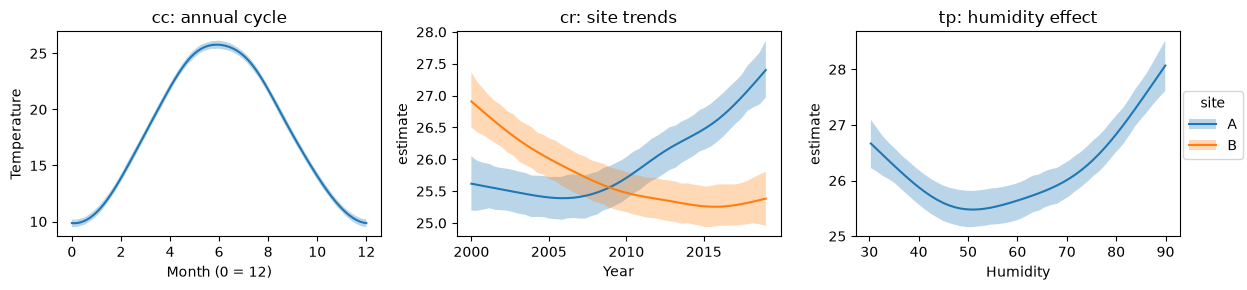

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), layout="tight")
bmb.interpret.plot_predictions(
    model, idata, {"month": np.linspace(0, 12, 100)}, on=axes[0]
)
bmb.interpret.plot_predictions(model, idata, ["year", "site"], on=axes[1])
bmb.interpret.plot_predictions(model, idata, ["humidity"], on=axes[2])

axes[0].set(xlabel="Month (0 = 12)", ylabel="Temperature", title="cc: annual cycle")
axes[1].set(xlabel="Year", title="cr: site trends")
axes[2].set(xlabel="Humidity", title="tp: humidity effect");